<a href="https://colab.research.google.com/github/arnabg2005/my-python-project/blob/main/Cyberbulling_BERT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [22]:
# 1. INSTALL & IMPORT
!pip install transformers datasets -q

import pandas as pd
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

from transformers import BertTokenizer, BertForSequenceClassification, Trainer, TrainingArguments


In [23]:
# 2. LOAD DATA
# ==============================
def load_data(path):
    df = pd.read_csv(path)
    df['label'] = df['label'].replace(-1, 1)
    return df

df = load_data('/content/final_dataset_hinglish.csv')

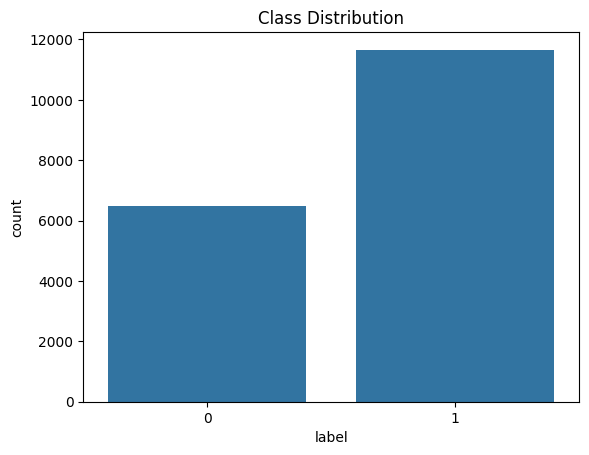

In [24]:
# 3. VISUALIZATION
# ==============================
def plot_class_distribution(df):
    sns.countplot(x=df['label'])
    plt.title("Class Distribution")
    plt.show()

plot_class_distribution(df)

In [25]:
# 4. SPLIT DATA
# ==============================
def split_data(df):
    return train_test_split(
        df['headline'].tolist(),
        df['label'].tolist(),
        test_size=0.3,
        random_state=42,
        stratify=df['label']
    )

train_texts, test_texts, train_labels, test_labels = split_data(df)

In [26]:
# 5. TOKENIZER (PIPELINE STEP)
# ==============================
def tokenize_data(train_texts, test_texts):
    tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

    train_encodings = tokenizer(train_texts, truncation=True, padding=True)
    test_encodings = tokenizer(test_texts, truncation=True, padding=True)

    return tokenizer, train_encodings, test_encodings

tokenizer, train_encodings, test_encodings = tokenize_data(train_texts, test_texts)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [27]:
# 6. DATASET CLASS
# ==============================
class Dataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = Dataset(train_encodings, train_labels)
test_dataset = Dataset(test_encodings, test_labels)

In [28]:
# 7. MODEL (PIPELINE STEP)
# ==============================
def load_model():
    return BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2)

model = load_model()

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
# 8. TRAINING SETUP
# ==============================
def train_model(model, train_dataset, test_dataset):
    training_args = TrainingArguments(
        output_dir='./results',
        num_train_epochs=2,
        per_device_train_batch_size=8,
        per_device_eval_batch_size=8,
        eval_strategy="epoch",
        logging_dir='./logs'
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=test_dataset
    )

    trainer.train()
    return trainer

trainer = train_model(model, train_dataset, test_dataset)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss


In [ ]:
# 9. PREDICTION (PIPELINE STEP)
# ==============================
def get_predictions(model, tokenizer, texts):
    preds = []
    for text in texts:
        inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True)
        outputs = model(**inputs)
        pred = outputs.logits.argmax().item()
        preds.append(pred)
    return preds

bert_preds = get_predictions(model, tokenizer, test_texts)


In [ ]:
# 10. EVALUATION
# ==============================
def evaluate(y_true, y_pred):
    print("\n===== BERT Evaluation =====\n")

    print("Accuracy :", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall   :", recall_score(y_true, y_pred))
    print("F1 Score :", f1_score(y_true, y_pred))

    print("\nClassification Report:\n")
    print(classification_report(y_true, y_pred))

evaluate(test_labels, bert_preds)


In [ ]:
# 11. CONFUSION MATRIX
# ==============================
def plot_confusion(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title("BERT Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

plot_confusion(test_labels, bert_preds)

In [ ]:
# 12. PERFORMANCE GRAPH
# ==============================
def plot_performance(y_true, y_pred):
    data = pd.DataFrame({
        'Metric': ['Accuracy', 'Precision', 'Recall', 'F1'],
        'Score': [
            accuracy_score(y_true, y_pred),
            precision_score(y_true, y_pred),
            recall_score(y_true, y_pred),
            f1_score(y_true, y_pred)
        ]
    })

    sns.barplot(x='Metric', y='Score', data=data)
    plt.title("BERT Performance")
    plt.ylim(0,1)
    plt.show()

plot_performance(test_labels, bert_preds)

In [ ]:
# 13. ERROR ANALYSIS
# ==============================
def error_analysis(texts, y_true, y_pred):
    print("\n===== Error Analysis =====\n")

    for text, t, p in zip(texts, y_true, y_pred):
        if t != p:
            print("Text:", text)
            print("Actual:", t, "Predicted:", p)
            print("------")
            break  # show few

error_analysis(test_texts, test_labels, bert_preds)

In [ ]:
# 14. REAL-TIME PREDICTION
# ==============================
def predict(text):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True)
    outputs = model(**inputs)
    pred = outputs.logits.argmax().item()
    return "Bullying" if pred == 1 else "Non-Bullying"

# test
sample = "you are a stupid idiot"
print("\nInput:", sample)
print("Prediction:", predict(sample))